<a href="https://colab.research.google.com/github/FRA-0023/Causal-Networks/blob/main/notebooks/Structural_causal_models.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
%%capture
!pip install networkx numpy pandas statsmodels

In [2]:
import networkx as nx  # Import the networkx library, commonly used for creating and manipulating graphs.
import numpy as np  # Import numpy for numerical operations, aliased as 'np' for convenience.
import pandas as pd  # Import pandas for data manipulation and analysis, aliased as 'pd'.
import statsmodels.api as sm  # Import statsmodels for statistical modeling, aliased as 'sm'.
from typing import Set  # Import 'Set' from the typing module for type hinting, indicating a collection of unique elements.

# Structural Causal Models

By Alessio Zanga, Niccolò Rocchi and Fabio Stella

## Abstract

This notebook illustrates a step-by-step example on estimating the average causal effect (ACE) given the appropriate backdoor adjustment set.

## Introduction

Continuing from [the previous example](https://colab.research.google.com/github/madlabunimib/F1801Q161-CausalNetworks/blob/main/notebooks/potential_outcomes.ipynb), the complete **systolic blood pressure** vs **sodium intake** causal graph is represented below.

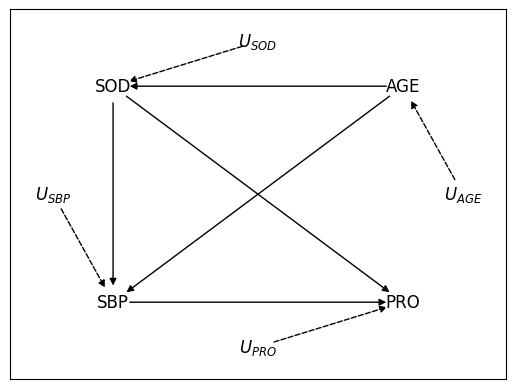

In [3]:
G = nx.DiGraph()  # Initialize an empty directed graph (DiGraph) using networkx.
# Define edges representing exogenous variables (U) influencing endogenous variables.
E_U = [("$U_{AGE}$", "AGE"), ("$U_{SOD}$", "SOD"), ("$U_{SBP}$", "SBP"), ("$U_{PRO}$", "PRO")]
# Define edges representing causal relationships between endogenous variables.
E_V = [("SOD", "SBP"), ("AGE", "SOD"), ("AGE", "SBP"), ("SOD", "PRO"), ("SBP", "PRO")]
G.add_edges_from(E_U + E_V)  # Add all defined edges (exogenous and endogenous) to the graph.
pos = nx.circular_layout(G)  # Compute a circular layout for visualizing the graph nodes.
_ = nx.draw_networkx_labels(G, pos)  # Draw the node labels on the graph using the specified position layout.
sty = {"min_source_margin": 12, "min_target_margin": 12}  # Define styling for edge drawing to prevent labels from overlapping edges.
_ = nx.draw_networkx_edges(G, pos, E_U, style="dashed", **sty)  # Draw exogenous edges with a dashed style.
_ = nx.draw_networkx_edges(G, pos, E_V, style="solid", **sty)  # Draw endogenous edges with a solid style.

In [1]:
%%capture
# Install necessary libraries: networkx for graph operations, numpy for numerical operations, pandas for data manipulation, and statsmodels for statistical modeling.
!pip install networkx numpy pandas statsmodels

You are now able to match the previous **causal graph** to the sampling function, defining the associated **structural causal model (SCM)**.

The complete specification of the casual model $\mathcal{M}$ is given by $\mathcal{M} = <U, V, F>$, where:

- $U = \{ U_{AGE}, \, U_{SOD}, \, U_{SBP}, \, U_{PRO} \}$,
- $V = \{ AGE, \, SOD, \, SBP, \, PRO \}$,
- $F = \{ f_{AGE}, f_{SOD}, f_{SBP}, f_{PRO} \}$.

In [4]:
def sample_data(size: int = int(1e6), seed: int = 31):
    # Define a function to sample data based on the structural causal model.
    # 'size' determines the number of samples, 'seed' ensures reproducibility.
    np.random.seed(seed)  # Set the random seed for numpy to make results reproducible.
    # Sample 'AGE' data from a normal distribution with mean 65 and standard deviation 5.
    age = np.random.normal(65, 5, size)
    # Sample 'SOD' (Sodium) data. It is influenced by 'AGE' and additive noise.
    sod = 0.056 * age + np.random.normal(0, 1, size)
    # Binarize 'SOD' based on a cutoff of 3.5. Values > 3.5 become 1, otherwise 0.
    sod = (sod > 3.5).astype(int)
    # Sample 'SBP' (Systolic Blood Pressure) data. It is influenced by 'SOD', 'AGE', and noise.
    sbp = 1.05 * sod + 2 * age + np.random.normal(0, 1, size)
    # Sample 'PRO' (Urinary Protein) data. It is influenced by 'SOD', 'SBP', and noise.
    pro = 0.4 * sod + 0.3 * sbp + np.random.normal(0, 1, size)
    # Create a pandas DataFrame from the sampled variables and return it.
    return pd.DataFrame({"AGE": age, "SOD": sod, "SBP": sbp, "PRO": pro})

Indeed, each line in this sampling function is a **structural equation** related to the **causal graph**:


\begin{cases}
AGE := f_{AGE}(U_{AGE}) = \mathcal{N}(65, 5) = 65 + \sqrt{5}\mathcal{N}(0, 1) \\
SOD := f_{SOD}(AGE, U_{SOD}) = I\left[0.056 \cdot AGE + \mathcal{N}(0, 1)\right] > 3.50 \\
SBP := f_{SBP}(AGE, SOD, U_{SBP}) = 1.05 \cdot SOD + 2.00 \cdot AGE + \mathcal{N}(0, 1) \\
PRO := f_{PRO}(SOD, SBP, U_{PRO}) = 0.40 \cdot SOD + 0.30 \cdot SBP + \mathcal{N}(0, 1)
\end{cases}

where $\mathcal{N}(\mu, \sigma^2)$ is a Gaussian noise with $\mu$ mean and $\sigma$ standard deviation and $I[X > x]$ is the indicator function.

Recall that the true ACE is given by the coefficient 1.05 that assign SBP a value given SOD.

In [5]:
data = sample_data()  # Generate a dataset by calling the 'sample_data' function.
data.describe()  # Display descriptive statistics (count, mean, std, min, max, quartiles) of the generated data.

,AGE,SOD,SBP,PRO
count,1000000.000000,1000000.000000,1000000.000000,1000000.000000
mean,65.001134,0.552995,130.583161,39.396720
std,4.993518,0.497184,10.161539,3.263477
min,40.964418,0.000000,82.816817,24.421988
25%,61.627703,0.000000,123.720103,37.190745
50%,65.009236,1.000000,130.597297,39.402344
75%,68.372794,1.000000,137.445514,41.602773
max,87.717317,1.000000,176.708462,54.573313


## Methods

Assuming consistency, positivity, and unconfoundedness, the average causal effect (ACE) is defined:

In [6]:
def ACE(data: pd.DataFrame, X: str, Y: str, Z: Set[str]):
    # Define a function to estimate the Average Causal Effect (ACE).
    # 'data': input DataFrame, 'X': treatment variable, 'Y': outcome variable, 'Z': adjustment set.
    # Define the regression model formula. It starts with Y ~ X.
    formula = f"{Y} ~ {X}"
    # If the adjustment set Z is not empty, add its variables to the formula.
    if len(Z) != 0: formula += "+" + "+".join(Z)
    # Fit an Ordinary Least Squares (OLS) regression model using the defined formula and data.
    estimator = sm.OLS.from_formula(formula, data).fit()
    # Compute potential outcomes by fixing the treatment variable X to 1 for all observations.
    Y1 = estimator.predict(data.assign(**{X: 1}))
    # Compute potential outcomes by fixing the treatment variable X to 0 for all observations.
    Y0 = estimator.predict(data.assign(**{X: 0}))
    # Compute the average causal effect as the mean difference between Y1 and Y0.
    return np.mean(Y1 - Y0)

A set of variables **Z** satisfies the backdoor criterion relative to an ordered pair of variables (X, Y) if:

- No node in **Z** is a descendant of X; and
- **Z** blocks every path between X and Y that contains an arrow into X.

While the former condition is clearly stated, the latter could be obscure and should be investigated further. Stating that **"Z blocks every path (...)"** might be misleading. In this context, **blocking** is intended as **d-separing**, which maps the first part to **"Z d-separes every path (...)"**. Moreover, **"(...) that contains an arrow into X"** is a convoluted expression which refers to the **parents of X**.

In [7]:
def is_d_separated(G: nx.DiGraph, X: Set[str], Y: Set[str], Z: Set[str]) -> bool:
    # Define a function to check if X and Y are d-separated by Z in graph G.
    # 'G': the directed graph, 'X', 'Y', 'Z': sets of nodes.
    # If X, Y, or Z share any common nodes, they are considered d-separated by definition in this context.
    if X & Z or Y & Z:
        return True
    # Otherwise, use networkx's built-in function to check for d-separation.
    return nx.is_d_separator(G, X, Y, Z)

One might be tempted to translate this condition as:
$$
Pa(X) \perp \!\!\! \perp_G Y~ | ~\textbf{Z}
$$
but it would be incomplete: following the definition of d-separation, X, Y and **Z** are required to be disjoint. Therefore,  **Z** alone would not be sufficient to block *every path between X and Y*, indeed some *direct* path from X to Y is still open. The correct translation is:
$$
Pa(X) \perp \!\!\! \perp_G Y~|~\textbf{Z} \cup \{ X \}
$$
where X itself blocks the direct path from X to Y, while **Z** blocks any *indirect* path from $Pa(X)$ to $Y$.

In [8]:
def is_backdoor_adjustement_set(G: nx.DiGraph, X: str, Y: str, Z: Set[str]) -> bool:
    # Define a function to check if Z is a valid backdoor adjustment set for (X, Y) in graph G.
    # 'G': the directed graph, 'X': treatment, 'Y': outcome, 'Z': candidate adjustment set.
    # Condition (i): no node in Z can be a descendant of X.
    if Z & nx.descendants(G, X):
        return False
    # Condition (ii): Z blocks every path between X and Y that contains an arrow into X.
    # This is achieved by checking if the parents of X (W) are d-separated from Y by Z union {X}.
    return all(is_d_separated(G, {W}, {Y}, Z | {X}) for W in G.predecessors(X))

## Results

The true ACE is:

In [9]:
ace = 1.05  # Define the true Average Causal Effect (ACE) as per the model's structural equation.

The naive estimated ACE without adjustment is:

In [10]:
t = ACE(data, X = "SOD", Y = "SBP", Z = set())  # Estimate ACE without any adjustment (Z is an empty set).
# Format and print the estimated ACE and its relative error compared to the true ACE.
f"Estimated ACE: {t:.3}, Relative Error: {(np.abs((t-ace)/ace*100)):.4}%"

'Estimated ACE: 5.37, Relative Error: 411.5%'

Indeed it exists a backdoor path between $X$ and $Y$, thus the empty set is not a valid adjustment set since it doesn't block this backdoor path:

In [11]:
is_backdoor_adjustement_set(G, X = "SOD", Y = "SBP", Z = set())  # Check if the empty set is a valid backdoor adjustment set for (SOD, SBP).

False

The estimated ACE adjusting for AGE and PRO is:

In [12]:
t = ACE(data, X = "SOD", Y = "SBP", Z = {"AGE", "PRO"})  # Estimate ACE adjusting for 'AGE' and 'PRO'.
# Format and print the estimated ACE and its relative error.
f"Estimated ACE: {t:.3}, Relative Error: {(np.abs((t-ace)/ace*100)):.4}%"

'Estimated ACE: 0.856, Relative Error: 18.46%'

Let's check if $Z = \{ AGE, PRO \}$ is a backdoor adjustment set:

In [13]:
is_backdoor_adjustement_set(G, X = "SOD", Y = "SBP", Z = {"AGE", "PRO"})  # Check if {'AGE', 'PRO'} is a valid backdoor adjustment set for (SOD, SBP).

False

Indeed, we add bias by conditioning on $PRO$ since it is a collider. Let's check if $Z$ **without** $PRO$ is a backdoor adjustment set:

In [14]:
is_backdoor_adjustement_set(G, X = "SOD", Y = "SBP", Z = {"AGE"})  # Check if {'AGE'} alone is a valid backdoor adjustment set for (SOD, SBP).

True

Then, the right estimation of ACE is the one we obtain by adjusting for AGE alone:

In [15]:
t = ACE(data, X = "SOD", Y = "SBP", Z = {"AGE"})  # Estimate ACE adjusting only for 'AGE'.
# Format and print the estimated ACE and its relative error.
f"Estimated ACE: {t:.4}, Relative Error: {(np.abs((t-ace)/ace*100)):.4}%"

'Estimated ACE: 1.052, Relative Error: 0.2269%'

## Conclusions

Applying a naive regression model without adjustment leads to an estimated ACE which is four times off. A regression model with an adjustment set reduce the relative error to 18%. Instead, using a **backdoor** adjustment set lowered it to 0.2%.

## Additional material

If you want to enjoy your learning, get a look at [DAGitty](https://dagitty.net/dags.html)! It is an interesting web-based graphical tool that allows you to experiment with custom settings and familiarize with Causal Networks concepts.